📘 Notebook: Court Case Backlog & Delay Analysis

1. Setup

In [30]:
# Install if needed
# !pip install requests pandas matplotlib seaborn

import requests
import pandas as pd
import time
import matplotlib.pyplot as plt

🔹 2. API Configuration

In [31]:
TOKEN = "03aff4672ad061fa70a808bc3e81d802013fa865"
BASE_URL = "https://www.courtlistener.com/api/rest/v4/dockets/"
TARGET_COUNT = 1000

🔹 3. Data Ingestion (Robust Pagination)

In [ ]:
def fetch_dockets(limit=100):
    headers = {'Authorization': f'Token {TOKEN}'}
    params = {'date_filed__lt': '2025-01-01'} 
    
    all_records = []
    next_url = BASE_URL

    print(f"Fetching up to {limit} records...")

    while next_url and len(all_records) < limit:
        try:
            response = requests.get(
                next_url,
                headers=headers,
                params=params if next_url == BASE_URL else None
            )

            if response.status_code == 429:
                print("Rate limit hit. Sleeping...")
                time.sleep(5)
                continue

            response.raise_for_status()
            data = response.json()

            batch = data.get('results', [])
            all_records.extend(batch)

            print(f"Collected {len(all_records)} records...")
            next_url = data.get('next')

        except requests.exceptions.RequestException as e:
            print(f"Error: {e}")
            break

    return all_records[:limit]


records = fetch_dockets(TARGET_COUNT)

Fetching up to 1000 records...
Error: 400 Client Error: Bad Request for url: https://www.courtlistener.com/api/rest/v4/dockets/?ordering=-id


🔹 4. Convert to Structured DataFrame

In [33]:
df = pd.DataFrame(records)

df = df[[
    "id",
    "court_id",
    "case_name",
    "date_filed",
    "date_terminated"
]]

df.columns = [
    "case_id",
    "court_id",
    "case_name",
    "date_filed",
    "date_terminated"
]

df.head()

,case_id,court_id,case_name,date_filed,date_terminated
0,73242889,paed,United States v. VITOLO.,2024-06-13,None
1,73242750,ksd,Request Certificate of Good Standing,2013-09-19,None
2,73242642,nysd,"Glasstech,Inc. v. Freund",2023-07-12,None
3,73241929,orb,Denise Lynn Mann,2024-01-09,None
4,73241728,nysd,Eddi v. Antebi,2024-01-24,None


🔹 5. Data Cleaning & Feature Engineering

📌 Definitions
duration = time to resolution
is_active = case not terminated
year variables = temporal aggregation

In [34]:
df["date_filed"] = pd.to_datetime(df["date_filed"])
df["date_terminated"] = pd.to_datetime(df["date_terminated"], errors="coerce")

df = df[df["date_filed"].notna()]

df["duration_months"] = (df["date_terminated"] - df["date_filed"]).dt.days / 30

df["year_filed"] = df["date_filed"].dt.year
df["year_terminated"] = df["date_terminated"].dt.year

df["is_active"] = df["date_terminated"].isna().astype(int)

df.head()

,case_id,court_id,case_name,date_filed,date_terminated,duration_months,year_filed,year_terminated,is_active
0,73242889,paed,United States v. VITOLO.,2024-06-13,NaT,NaN,2024,NaN,1
1,73242750,ksd,Request Certificate of Good Standing,2013-09-19,NaT,NaN,2013,NaN,1
2,73242642,nysd,"Glasstech,Inc. v. Freund",2023-07-12,NaT,NaN,2023,NaN,1
3,73241929,orb,Denise Lynn Mann,2024-01-09,NaT,NaN,2024,NaN,1
4,73241728,nysd,Eddi v. Antebi,2024-01-24,NaT,NaN,2024,NaN,1


🔹 6. Basic Descriptive Statistics

df["duration_months"].describe()

🔹 7. Focus on Closed Cases

In [35]:
df_closed = df[df["is_active"] == 0]

df_closed["duration_months"].describe()

count    291.000000
mean      15.371821
std       54.403550
min       -8.233333
25%        1.883333
50%        5.533333
75%       14.500000
max      782.633333
Name: duration_months, dtype: float64

🔹 8. Bottleneck Analysis (by Court)

In [36]:
court_duration = (
    df_closed
    .groupby("court_id")["duration_months"]
    .mean()
    .sort_values(ascending=False)
)

court_duration.head(10)

court_id
tnwd    465.700000
utd      86.900000
ndd      47.837879
insb     46.566667
vaed     40.266667
cacb     36.266667
mowb     34.780000
ca10     31.966667
ca9      31.346667
cadc     28.155556
Name: duration_months, dtype: float64

🔹 9. Distribution of Delays

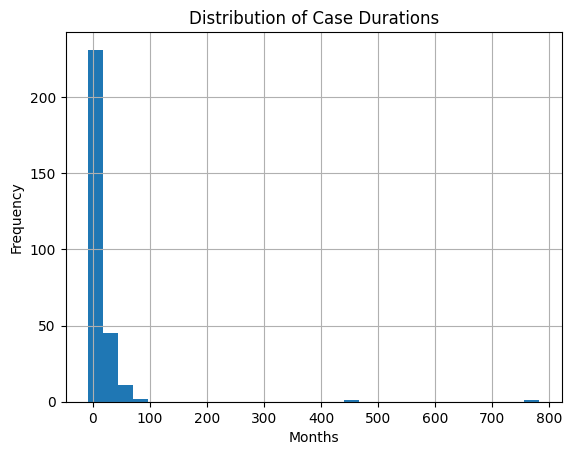

In [37]:
plt.figure()
df_closed["duration_months"].hist(bins=30)
plt.title("Distribution of Case Durations")
plt.xlabel("Months")
plt.ylabel("Frequency")
plt.show()

🔹 10. Flow Analysis (Inflow vs Outflow)

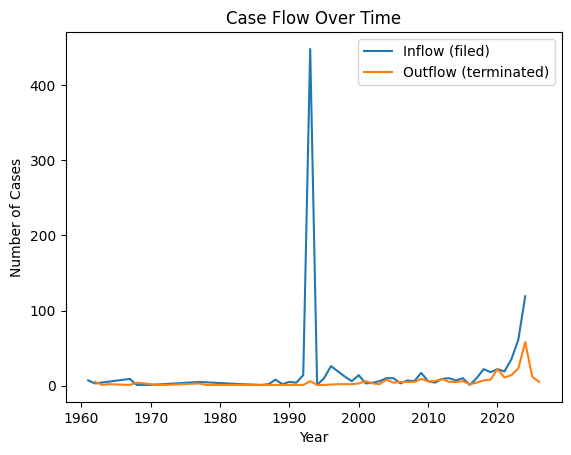

In [38]:
inflow = df.groupby("year_filed").size()
outflow = df_closed.groupby("year_terminated").size()

plt.figure()
inflow.plot(label="Inflow (filed)")
outflow.plot(label="Outflow (terminated)")
plt.legend()
plt.title("Case Flow Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.show()

🔥 11. Backlog Approximation (Core Concept)

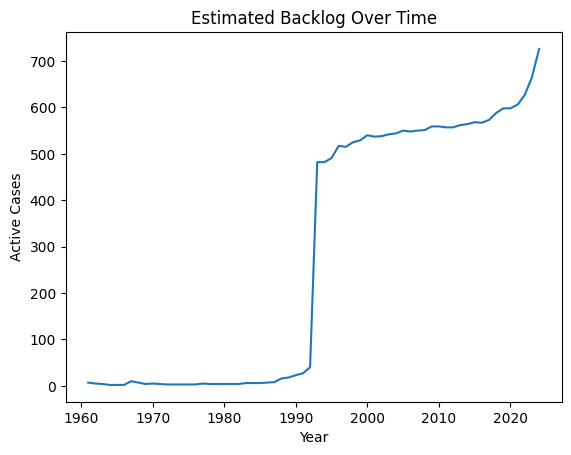

In [39]:
df["year_filed"] = df["date_filed"].dt.year
df["year_terminated"] = df["date_terminated"].dt.year

years = range(df["year_filed"].min(), df["year_filed"].max() + 1)

backlog = []

for y in years:
    active_cases = df[
        (df["year_filed"] <= y) &
        ((df["year_terminated"].isna()) | (df["year_terminated"] > y))
    ]
    backlog.append(len(active_cases))

plt.figure()
plt.plot(years, backlog)
plt.title("Estimated Backlog Over Time")
plt.xlabel("Year")
plt.ylabel("Active Cases")
plt.show()

In [41]:
with engine.connect() as conn:
    conn.execute(text("SET FOREIGN_KEY_CHECKS=0"))
    conn.execute(text("TRUNCATE TABLE case_docket"))
    conn.execute(text("SET FOREIGN_KEY_CHECKS=1"))

In [42]:
from sqlalchemy import create_engine, text

engine = create_engine("mysql+pymysql://root:@localhost/big_data")

df_sql = df[[
    "case_id",
    "court_id",
    "case_name",
    "date_filed",
    "date_terminated"
]].copy()

df_sql["date_terminated"] = df_sql["date_terminated"].fillna("1900-01-01")

df_sql["date_last_filing"] = df_sql["date_filed"]
df_sql["jurisdiction_type"] = "unknown"
df_sql["nature_of_suit"] = "unknown"
df_sql["cause"] = "unknown"
df_sql["status"] = "unknown"

# 🔴 AJOUT IMPORTANT
with engine.connect() as conn:
    conn.execute(text("SET FOREIGN_KEY_CHECKS=0"))

df_sql.to_sql("case_docket", engine, if_exists="append", index=False)

with engine.connect() as conn:
    conn.execute(text("SET FOREIGN_KEY_CHECKS=1"))

print("Data successfully written to MySQL")

Data successfully written to MySQL


In [43]:
df_sql = pd.read_sql("SELECT * FROM case_docket", engine)
df_sql.head()

,case_id,court_id,date_filed,date_terminated,date_last_filing,jurisdiction_type,nature_of_suit,cause,status,case_name
0,73090315,tex,1993-08-20,1900-01-01,1993-08-20,unknown,unknown,unknown,unknown,SHAROME M. McQUEEN v. THE HERTZ CORPORATION
1,73090316,tex,1993-08-18,1900-01-01,1993-08-18,unknown,unknown,unknown,unknown,ANHEUSER-BUSCH COMPANIES v. SUMMIT COFFEE COMPANY
2,73090317,tex,1993-08-23,1900-01-01,1993-08-23,unknown,unknown,unknown,unknown,"J1M1, INC., F/K/A 3D ORTHOPEDI v. GAIL SCHUMANN"
3,73090318,tex,1993-08-23,1900-01-01,1993-08-23,unknown,unknown,unknown,unknown,RICHARD McMAHAN v. JOHN LYNN NAYLOR
4,73090319,tex,1993-08-23,1900-01-01,1993-08-23,unknown,unknown,unknown,unknown,GEORGE R. GUNN v. JUDITH K. GUNN


AJOUTER case_metrics

In [44]:
df_metrics = df.copy()

df_metrics["duration_months"] = (
    (df_metrics["date_terminated"] - df_metrics["date_filed"])
    .dt.days / 30
)

df_metrics["year_filed"] = df_metrics["date_filed"].dt.year
df_metrics["year_terminated"] = df_metrics["date_terminated"].dt.year

df_metrics["is_active"] = df_metrics["date_terminated"].isna().astype(int)

df_metrics = df_metrics[[
    "case_id",
    "duration_months",
    "is_active",
    "year_filed",
    "year_terminated"
]]

df_metrics = df_metrics.fillna(0)

In [46]:
with engine.connect() as conn:
    conn.execute(text("SET FOREIGN_KEY_CHECKS=0"))
    conn.execute(text("TRUNCATE TABLE case_metrics"))
    conn.execute(text("SET FOREIGN_KEY_CHECKS=1"))

In [47]:
with engine.connect() as conn:
    conn.execute(text("SET FOREIGN_KEY_CHECKS=0"))

df_metrics.to_sql("case_metrics", engine, if_exists="append", index=False)

with engine.connect() as conn:
    conn.execute(text("SET FOREIGN_KEY_CHECKS=1"))

print("case_metrics written ✔")

case_metrics written ✔
